In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")
df.head() 

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [3]:
import pandas as pd
 
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

print("Shape:", df.shape)
print("Columns:", df.columns)
df.head()

Shape: (9712, 8)
Columns: Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [4]:
screen_df = pd.read_csv("Indian_Kids_Screen_Time.csv")

In [5]:
df.shape
df.columns
df.info()
df.describe()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [6]:
df.duplicated().sum()
df.drop_duplicates(inplace=True) 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9668 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9668 non-null   int64  
 1   Gender                             9668 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9668 non-null   float64
 3   Primary_Device                     9668 non-null   object 
 4   Exceeded_Recommended_Limit         9668 non-null   bool   
 5   Educational_to_Recreational_Ratio  9668 non-null   float64
 6   Health_Impacts                     6488 non-null   object 
 7   Urban_or_Rural                     9668 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 613.7+ KB


In [8]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
) 
df.head()

,age,gender,avg_daily_screen_time_hr,primary_device,exceeded_recommended_limit,educational_to_recreational_ratio,health_impacts,urban_or_rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [9]:
df.shape

(9668, 8)

In [10]:
df['health_impacts'].isnull().sum()

np.int64(3180)

In [11]:
df.columns

Index(['age', 'gender', 'avg_daily_screen_time_hr', 'primary_device',
       'exceeded_recommended_limit', 'educational_to_recreational_ratio',
       'health_impacts', 'urban_or_rural'],
      dtype='object')

In [12]:
df.describe()

,age,avg_daily_screen_time_hr,educational_to_recreational_ratio
count,9668.000000,9668.000000,9668.000000
mean,12.992760,4.367780,0.427028
std,3.158931,1.703002,0.073185
min,8.000000,0.000000,0.300000
25%,10.000000,3.427500,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [13]:
df.isnull().sum()

age                                     0
gender                                  0
avg_daily_screen_time_hr                0
primary_device                          0
exceeded_recommended_limit              0
educational_to_recreational_ratio       0
health_impacts                       3180
urban_or_rural                          0
dtype: int64

In [14]:
df['health_impacts'] = df['health_impacts'].fillna("No Health Impact")

In [15]:
df['health_impacts'].isnull().sum()

np.int64(0)

In [16]:
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

In [17]:
bins = [0,5,10,15,18]
labels = ['toddler','child','pre-teen','teen']

df['age_band'] = pd.cut(df['age'], bins=bins, labels=labels)

In [18]:
bins = [5,10,13,16,18]
labels = ["6-10","11-13","14-16","17-18"]

df["Age_Band"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

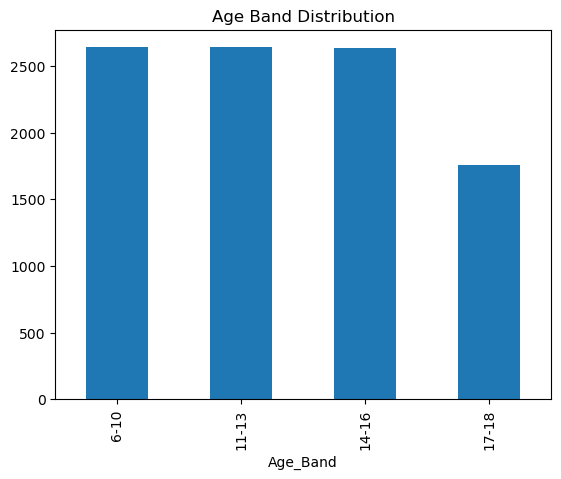

In [19]:
import matplotlib.pyplot as plt

plt.figure()
df["Age_Band"].value_counts().sort_index().plot(kind="bar")
plt.title("Age Band Distribution")
plt.show()

In [20]:
df["Day_Type"] = df["avg_daily_screen_time_hr"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

In [21]:
df['day_type'] = np.where(df['avg_daily_screen_time_hr']>4,'Weekend','Weekday')

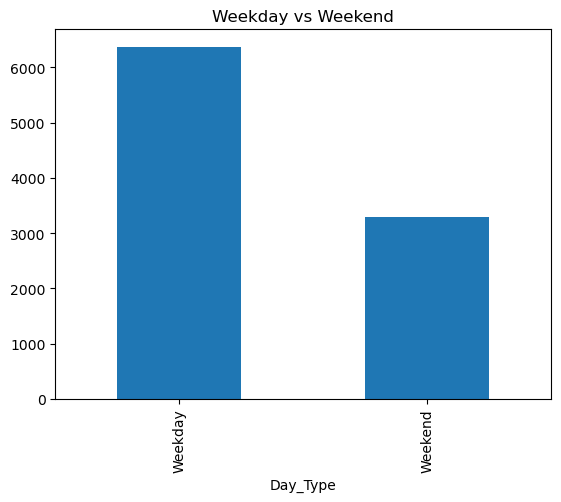

In [22]:
plt.figure()
df["Day_Type"].value_counts().plot(kind="bar")
plt.title("Weekday vs Weekend")
plt.show()

In [23]:
device_share = df['primary_device'].value_counts(normalize=True)

device_share

primary_device
Smartphone    0.469590
TV            0.256309
Laptop        0.148014
Tablet        0.126086
Name: proportion, dtype: float64

In [24]:
df['device_share'] = df['primary_device'].map(device_share)

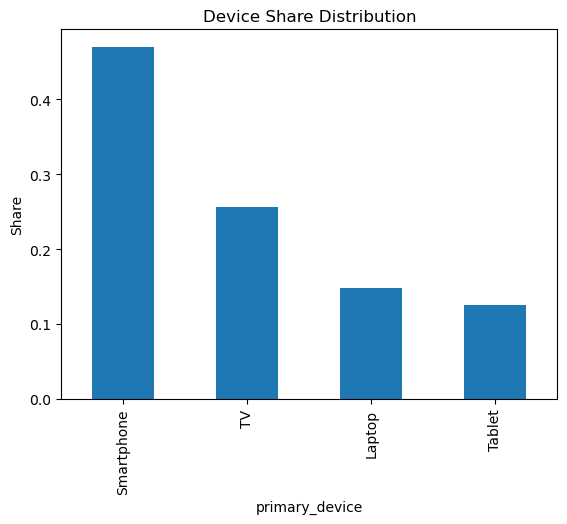

In [25]:
device_share.plot(kind='bar')
plt.title("Device Share Distribution")
plt.ylabel("Share")
plt.show()

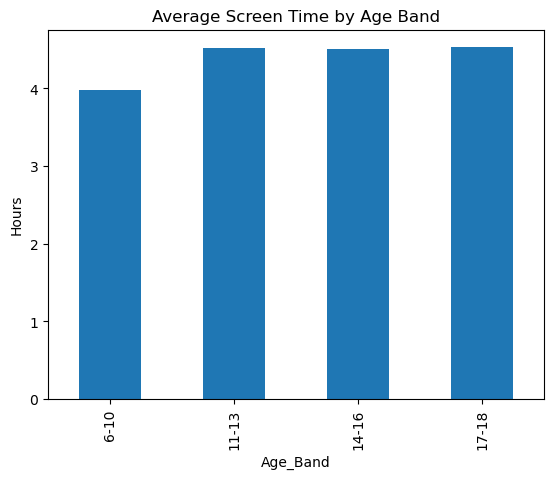

In [26]:
plt.figure()

df.groupby("Age_Band", observed=False)["avg_daily_screen_time_hr"].mean().plot(kind="bar")

plt.title("Average Screen Time by Age Band")
plt.ylabel("Hours")
plt.show()

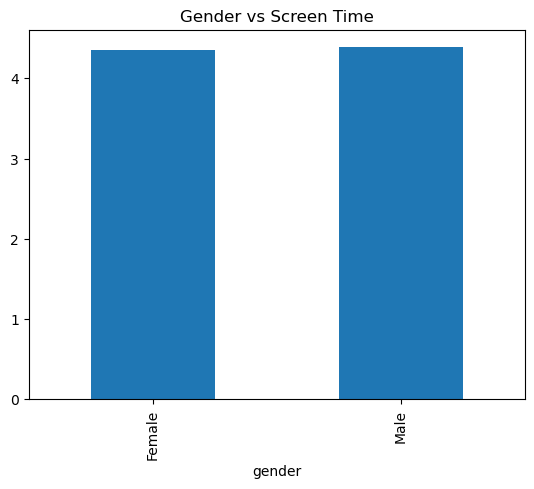

In [27]:
plt.figure()
df.groupby("gender")["avg_daily_screen_time_hr"].mean().plot(kind="bar")
plt.title("Gender vs Screen Time")
plt.show()

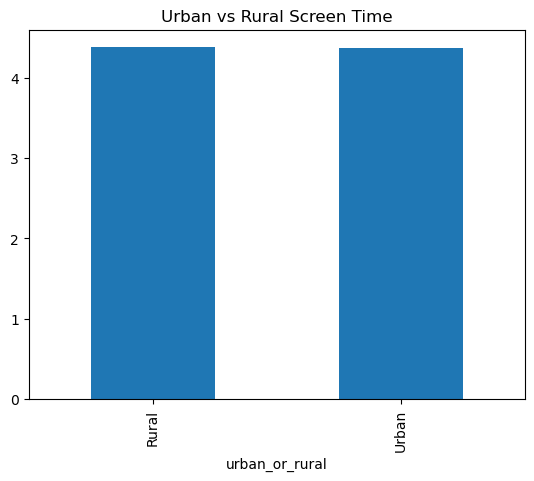

In [28]:
plt.figure()
df.groupby("urban_or_rural")["avg_daily_screen_time_hr"].mean().plot(kind="bar")
plt.title("Urban vs Rural Screen Time")
plt.show()

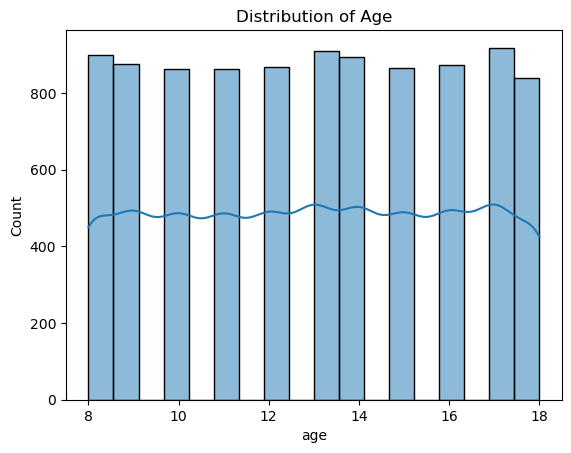

In [29]:
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Distribution of Age")
plt.show()

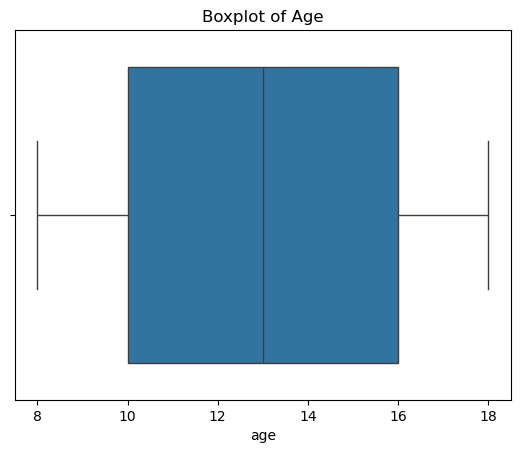

In [30]:
plt.figure()
sns.boxplot(x=df['age'])
plt.title("Boxplot of Age")
plt.show()

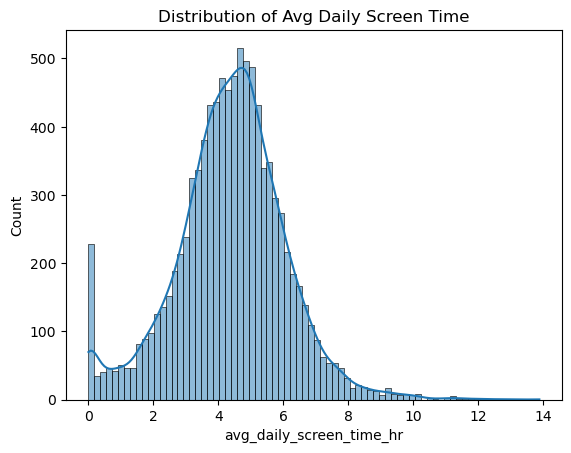

In [31]:
plt.figure()
sns.histplot(df['avg_daily_screen_time_hr'], kde=True)
plt.title("Distribution of Avg Daily Screen Time")
plt.show()

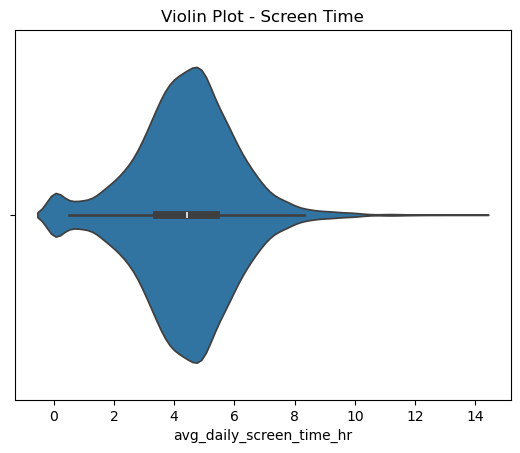

In [32]:
plt.figure()
sns.violinplot(x=df['avg_daily_screen_time_hr'])
plt.title("Violin Plot - Screen Time")
plt.show()

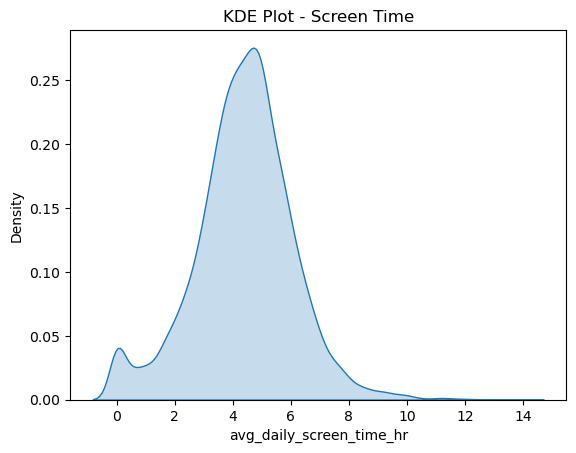

In [33]:
plt.figure()
sns.kdeplot(df['avg_daily_screen_time_hr'], fill=True)
plt.title("KDE Plot - Screen Time")
plt.show()

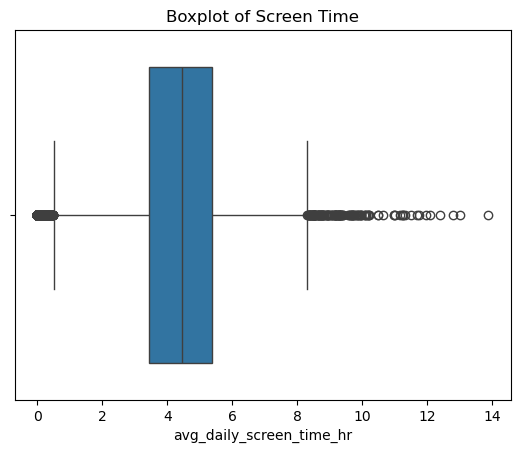

In [34]:
plt.figure()
sns.boxplot(x=df['avg_daily_screen_time_hr'])
plt.title("Boxplot of Screen Time")
plt.show()

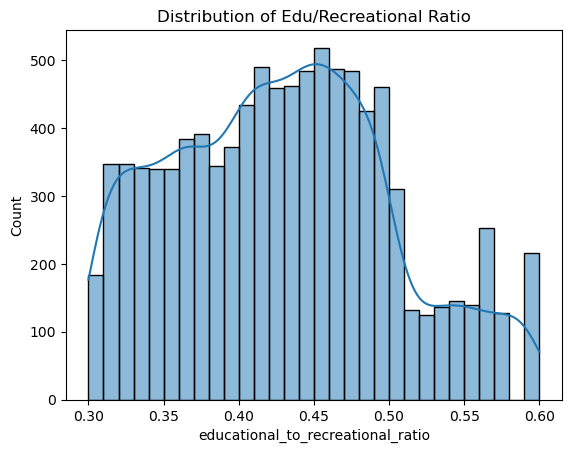

In [35]:
plt.figure()
sns.histplot(df['educational_to_recreational_ratio'], kde=True)
plt.title("Distribution of Edu/Recreational Ratio")
plt.show()

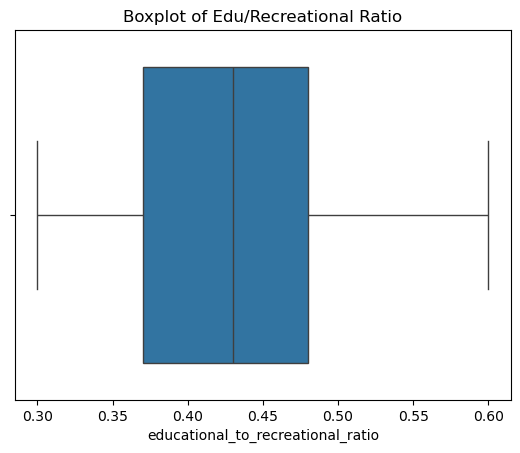

In [36]:
plt.figure()
sns.boxplot(x=df['educational_to_recreational_ratio'])
plt.title("Boxplot of Edu/Recreational Ratio")
plt.show()

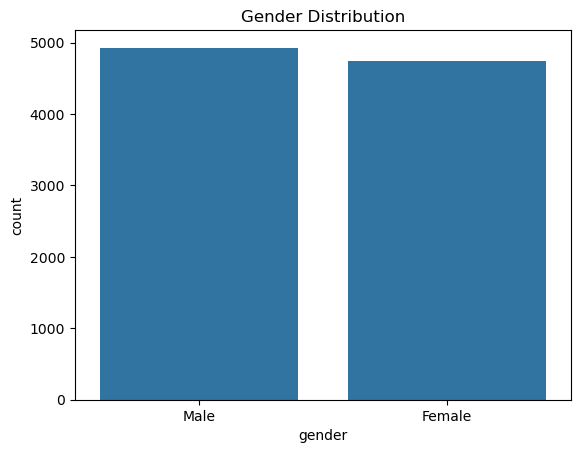

In [37]:
plt.figure()
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

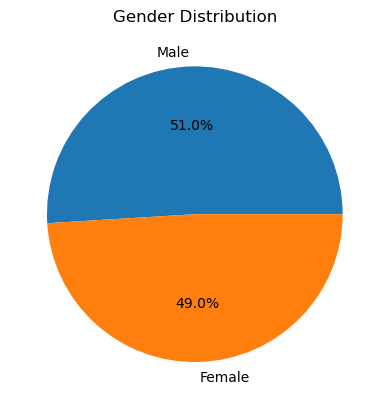

In [38]:
plt.figure()
df['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel('')
plt.show()

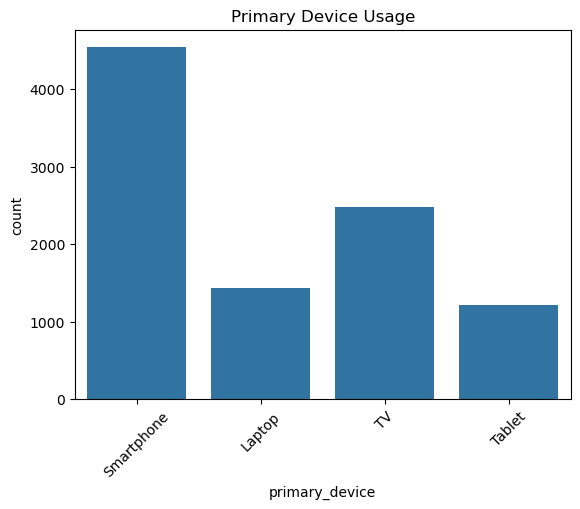

In [39]:
plt.figure()
sns.countplot(x='primary_device', data=df)
plt.xticks(rotation=45)
plt.title("Primary Device Usage")
plt.show()

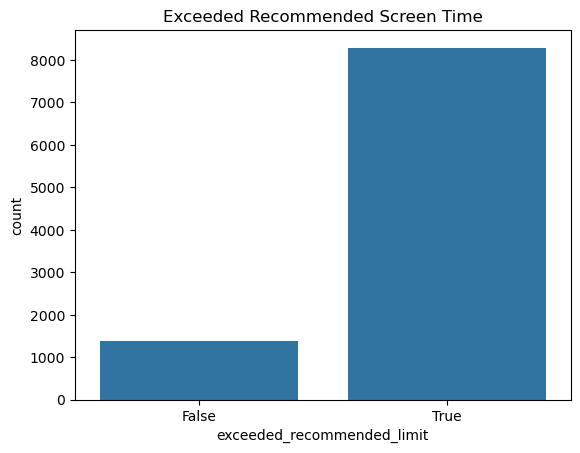

In [40]:
plt.figure()
sns.countplot(x='exceeded_recommended_limit', data=df)
plt.title("Exceeded Recommended Screen Time")
plt.show()

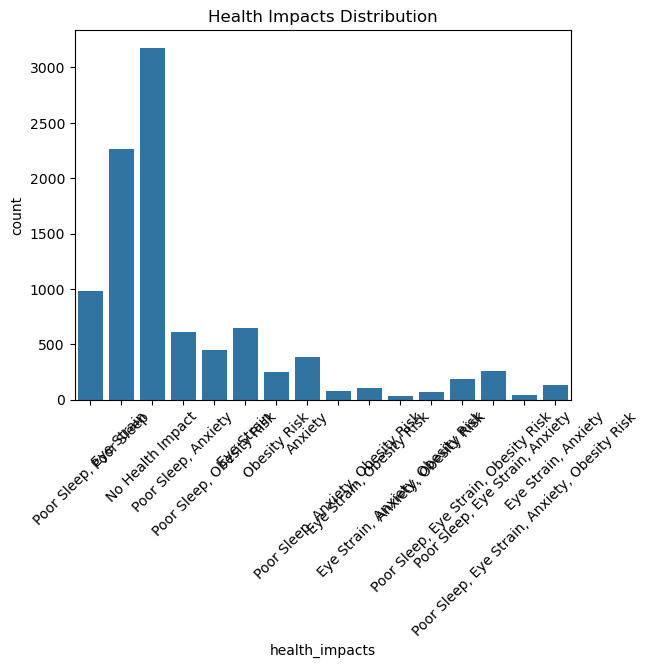

In [41]:
plt.figure()
sns.countplot(x='health_impacts', data=df)
plt.xticks(rotation=45)
plt.title("Health Impacts Distribution")
plt.show()

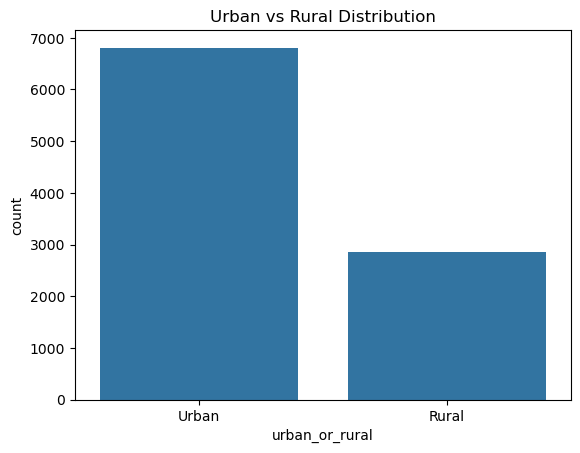

In [42]:
plt.figure()
sns.countplot(x='urban_or_rural', data=df)
plt.title("Urban vs Rural Distribution")
plt.show()

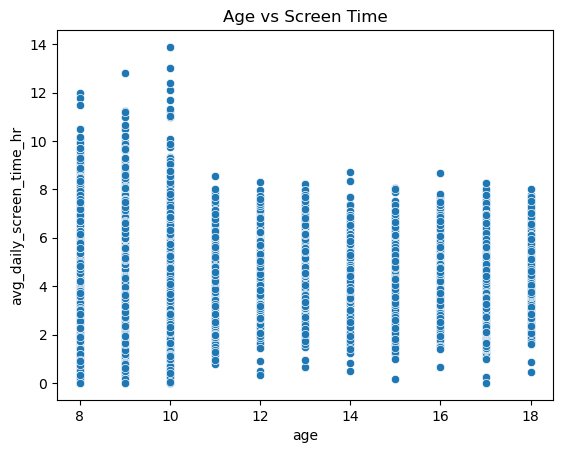

In [43]:
plt.figure()
sns.scatterplot(x='age', y='avg_daily_screen_time_hr', data=df)
plt.title("Age vs Screen Time")
plt.show()

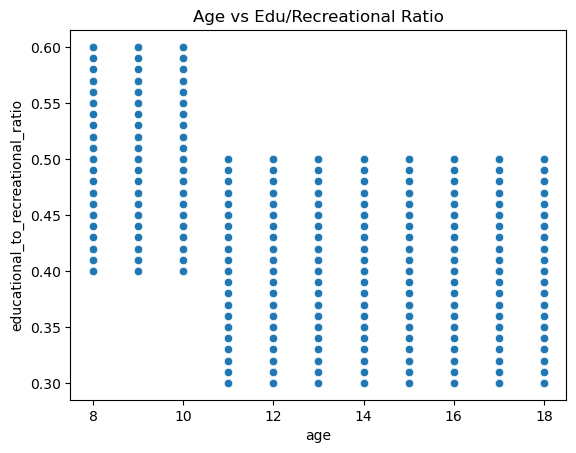

In [44]:
plt.figure()
sns.scatterplot(x='age', y='educational_to_recreational_ratio', data=df)
plt.title("Age vs Edu/Recreational Ratio")
plt.show()

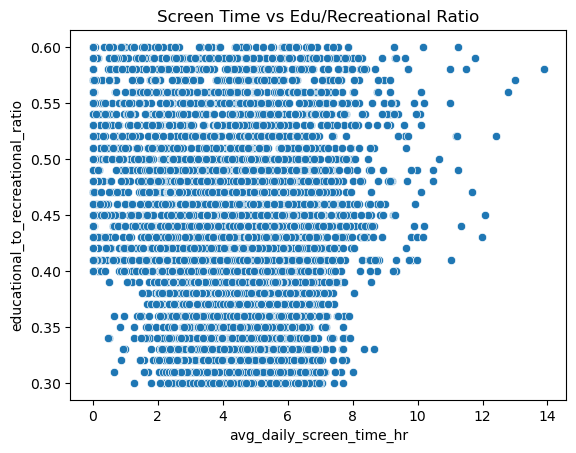

In [45]:
plt.figure()
sns.scatterplot(x='avg_daily_screen_time_hr',
                y='educational_to_recreational_ratio',
                data=df)
plt.title("Screen Time vs Edu/Recreational Ratio")
plt.show()

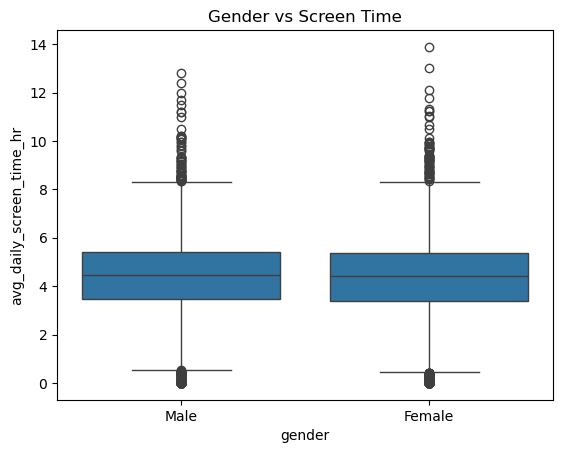

In [46]:
plt.figure()
sns.boxplot(x='gender', y='avg_daily_screen_time_hr', data=df)
plt.title("Gender vs Screen Time")
plt.show()

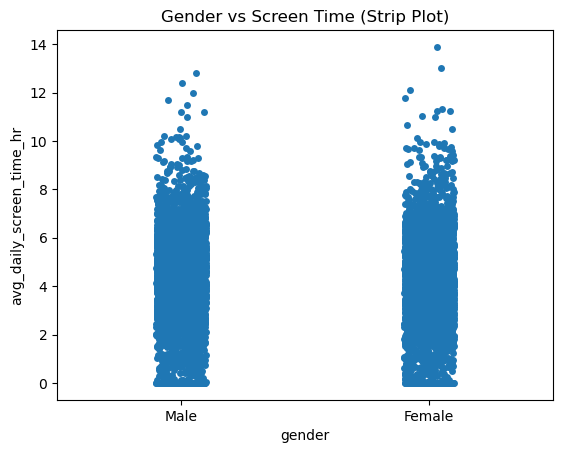

In [47]:
plt.figure()
sns.stripplot(x='gender',
              y='avg_daily_screen_time_hr',
              data=df)
plt.title("Gender vs Screen Time (Strip Plot)")
plt.show()

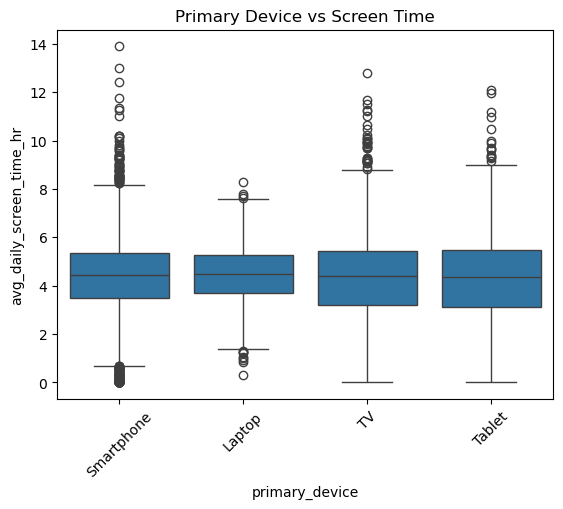

In [48]:
plt.figure()
sns.boxplot(x='primary_device', y='avg_daily_screen_time_hr', data=df)
plt.xticks(rotation=45)
plt.title("Primary Device vs Screen Time")
plt.show()

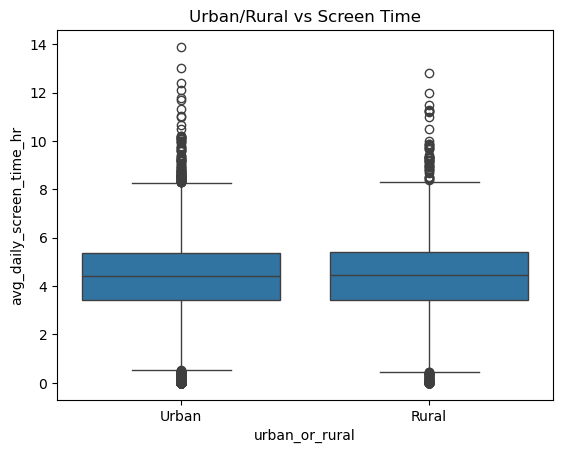

In [49]:
plt.figure()
sns.boxplot(x='urban_or_rural', y='avg_daily_screen_time_hr', data=df)
plt.title("Urban/Rural vs Screen Time")
plt.show()

In [50]:
import pandas as pd


data = {
    'Primary_Device': ['Mobile', 'TV', 'Laptop', 'Desktop', 'Tablet']
}
df = pd.DataFrame(data)

portable_devices = ['Mobile', 'Tablet', 'Laptop']
wall_mounted_devices = ['TV', 'Desktop']

df['Device_Category'] = df['Primary_Device'].apply(
    lambda x: 'Portable' if x in portable_devices else 'WallMounted'
)

df[['Primary_Device', 'Device_Category']].head()

,Primary_Device,Device_Category
0,Mobile,Portable
1,TV,WallMounted
2,Laptop,Portable
3,Desktop,WallMounted
4,Tablet,Portable


In [51]:
import pandas as pd
data = {
    'Activity': ['Online Classes', 'Gaming', 'Homework', 'YouTube', 'Social Media']
    
}
df = pd.DataFrame(data)
educational_activities = ['Online Classes', 'Homework', 'Learning Apps']
recreational_activities = ['Gaming', 'YouTube', 'Social Media', 'Entertainment']

df['Activity_Type'] = df['Activity'].apply(
    lambda x: 'Educational' if x in educational_activities else 'Recreational'
)

df[['Activity', 'Activity_Type']].head()

,Activity,Activity_Type
0,Online Classes,Educational
1,Gaming,Recreational
2,Homework,Educational
3,YouTube,Recreational
4,Social Media,Recreational


In [52]:
activity_ratio = (
    df['Activity_Type']
    .value_counts(normalize=True)
    .rename('ratio')
    .reset_index()
)

activity_ratio

,Activity_Type,ratio
0,Recreational,0.6
1,Educational,0.4
